Output directory: /content/outputs
GRADIENT BOOSTING COMPREHENSIVE ANALYSIS
Analysis started at: 2025-11-18 20:22:57

Loading datasets...
  - Threads: 9,284 rows
  - Comments: 9,188 rows
  - Grades: 848 rows

Normalizing time to week-of-course...
Courses found: 84

Building behavioral features per student...
Feature matrix: (4236, 16)

Building text corpus per student...
Corpus rows: (4236, 3)

Generating text embeddings...
  Using BERT (all-MiniLM-L6-v2)
  Embeddings shape: (4236, 384)

Computing semantic metrics...

Merging features with semantic metrics...

Filtering to students with valid grades...
Total students before filtering: 4,236
Students with valid grades: 149
Students filtered out (no grade): 4,087
Percentage with grades: 3.5%

Engineering interaction features...

Final feature count: 23
Total samples for training: 149
Grade distribution: min=0.00, max=1.00, mean=0.66, median=0.82


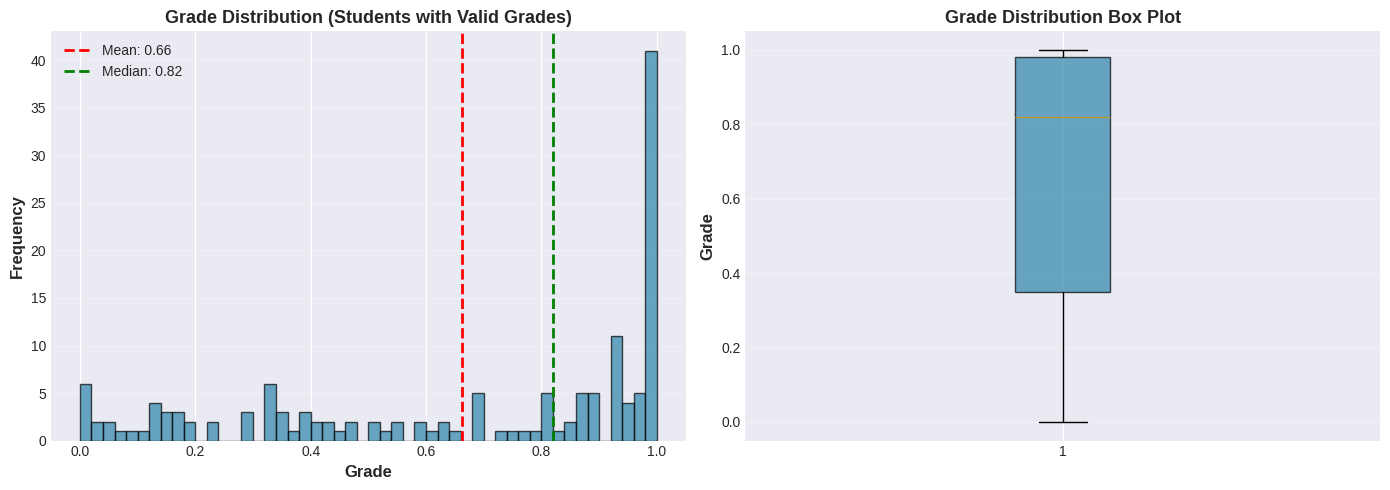


Grade distribution visualization saved.

GRADIENT BOOSTING MODEL

Train set: 111 samples
Test set: 38 samples

Training Gradient Boosting Regressor...

--------------------------------------------------
MODEL PERFORMANCE METRICS
--------------------------------------------------
Training R²:   0.9605
Test R²:       0.1533
Training MAE:  0.0465 (4.65% grade points)
Test MAE:      0.2717 (27.17% grade points)
Training RMSE: 0.0660
Test RMSE:     0.3381

--------------------------------------------------
MODEL HYPERPARAMETERS
--------------------------------------------------
Number of estimators: 400
Learning rate: 0.05
Max depth: 5
Subsample ratio: 0.9
Min samples split: 20
Min samples leaf: 10
Max features: sqrt

--------------------------------------------------
TOP 20 FEATURE IMPORTANCES
--------------------------------------------------
topic_x_entropy                     0.11858
topic_x_active                      0.09951
avg_comment_len                     0.08289
local_topic_ent

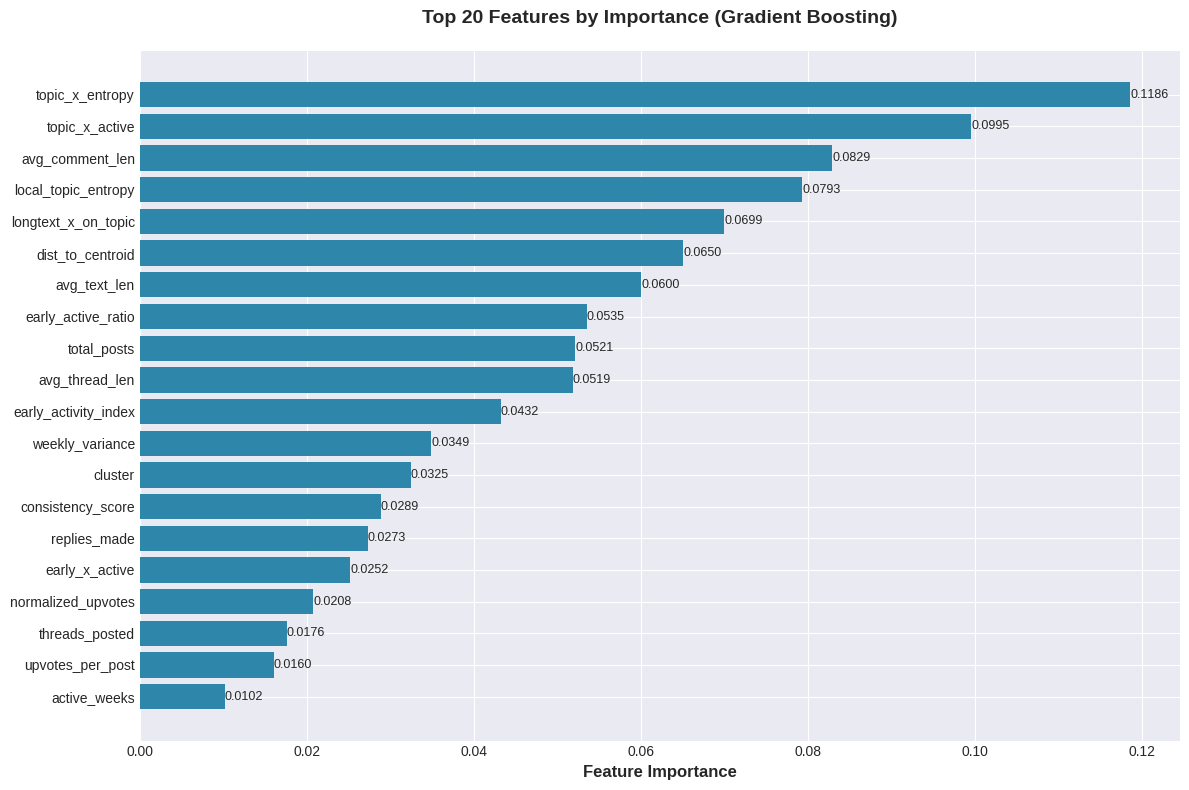

2. Cumulative Feature Importance...


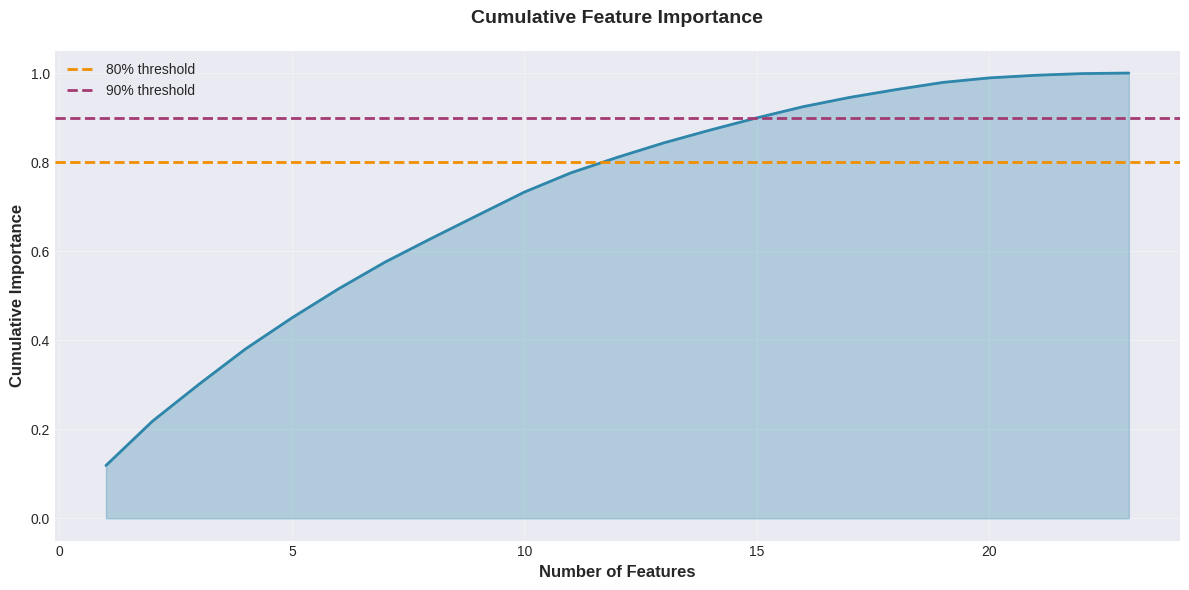

3. Predictions vs Actual Scatter Plots...


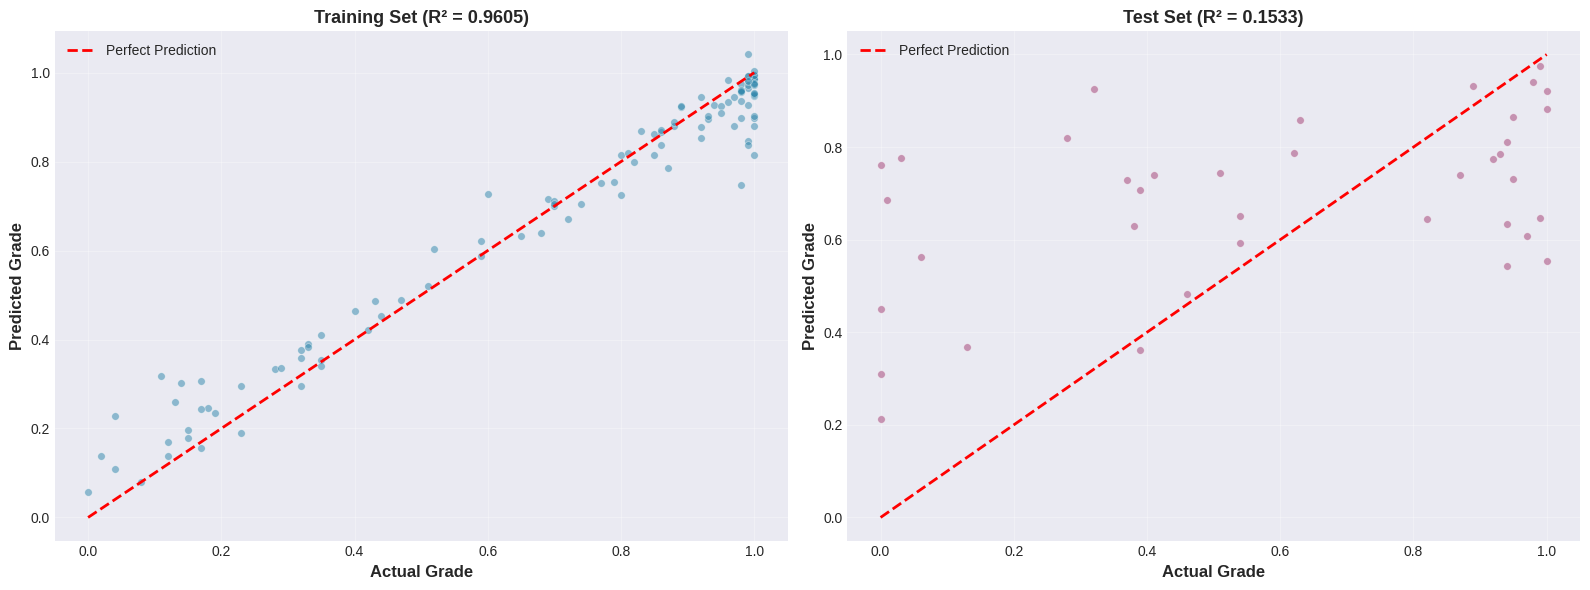

4. Residual Analysis...


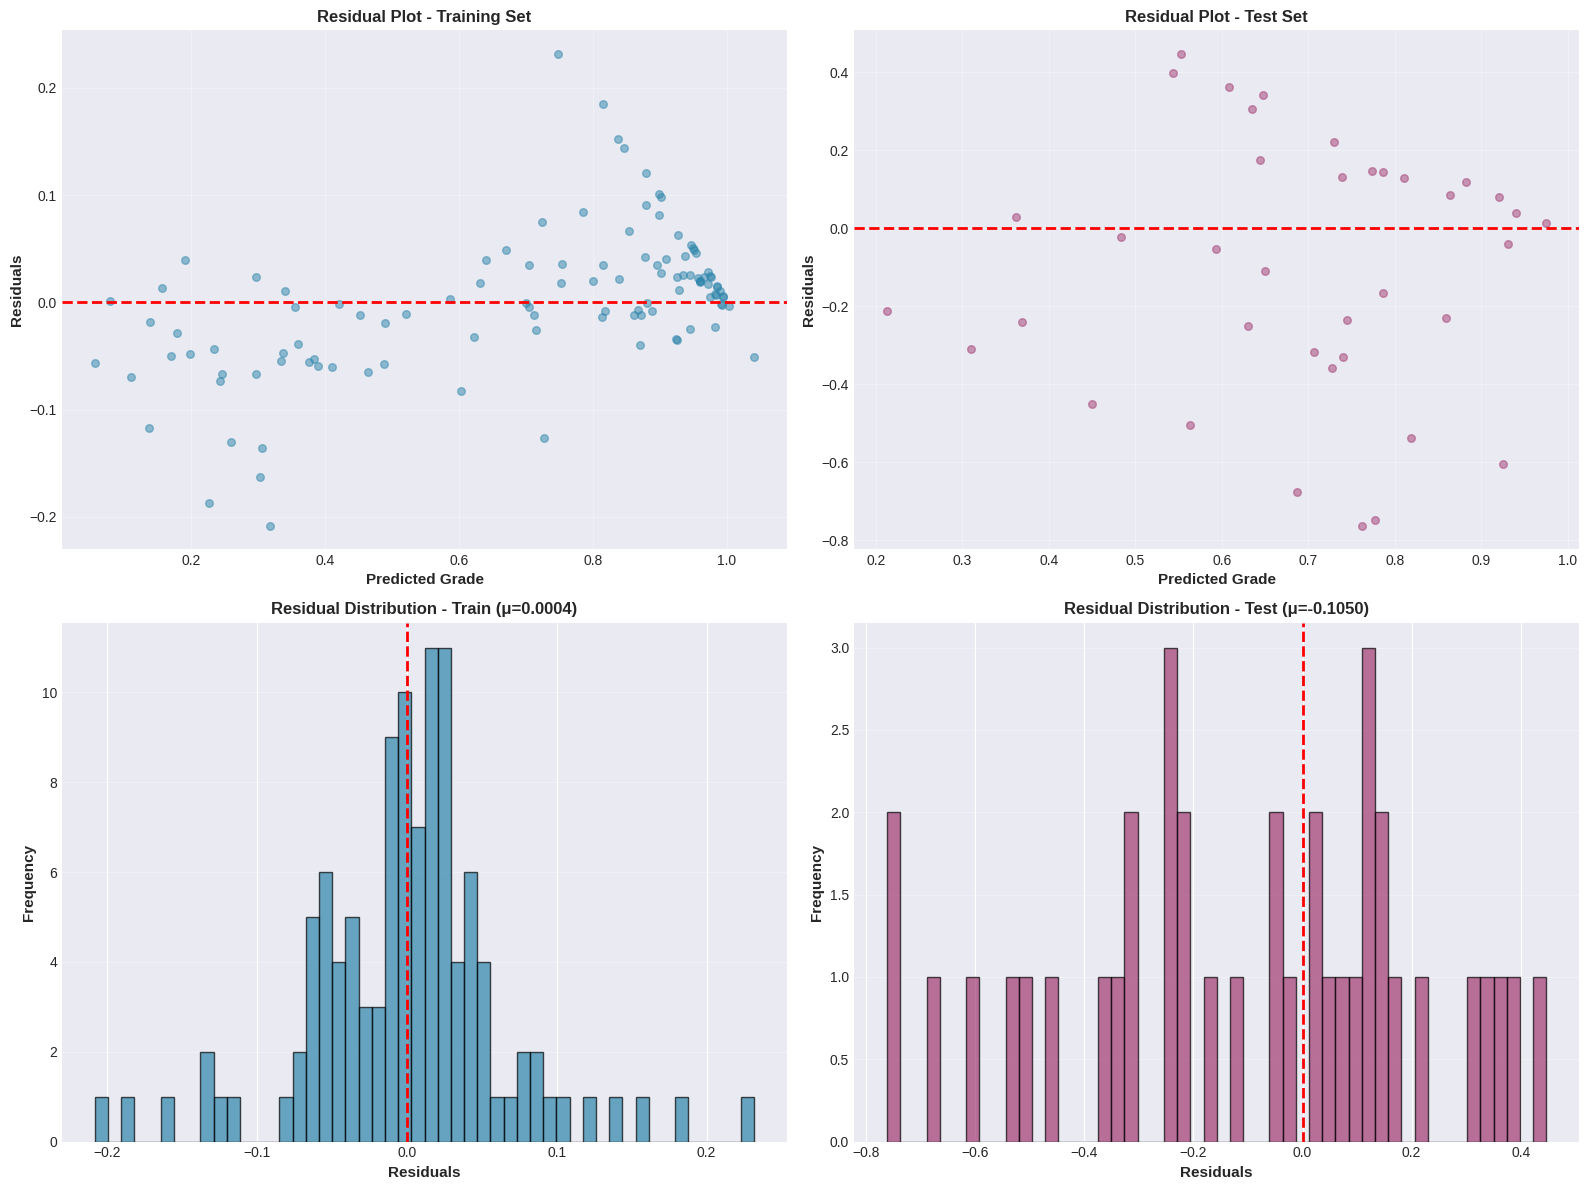

5. Feature Correlation Heatmap...


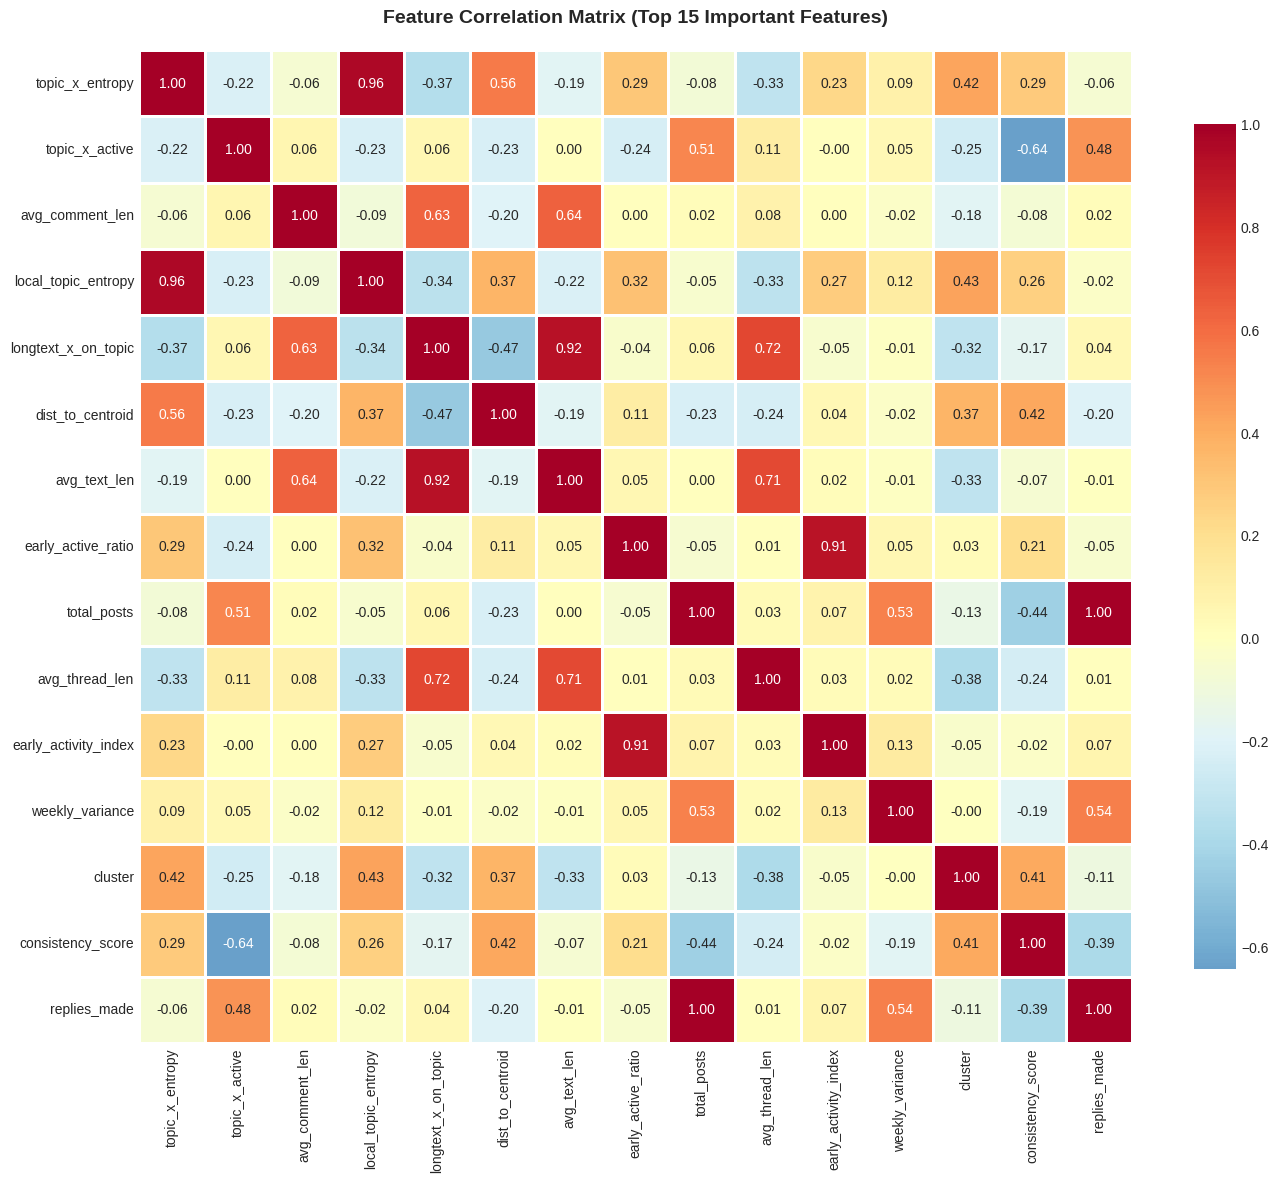

6. Feature-Grade Relationship Scatter Plots...


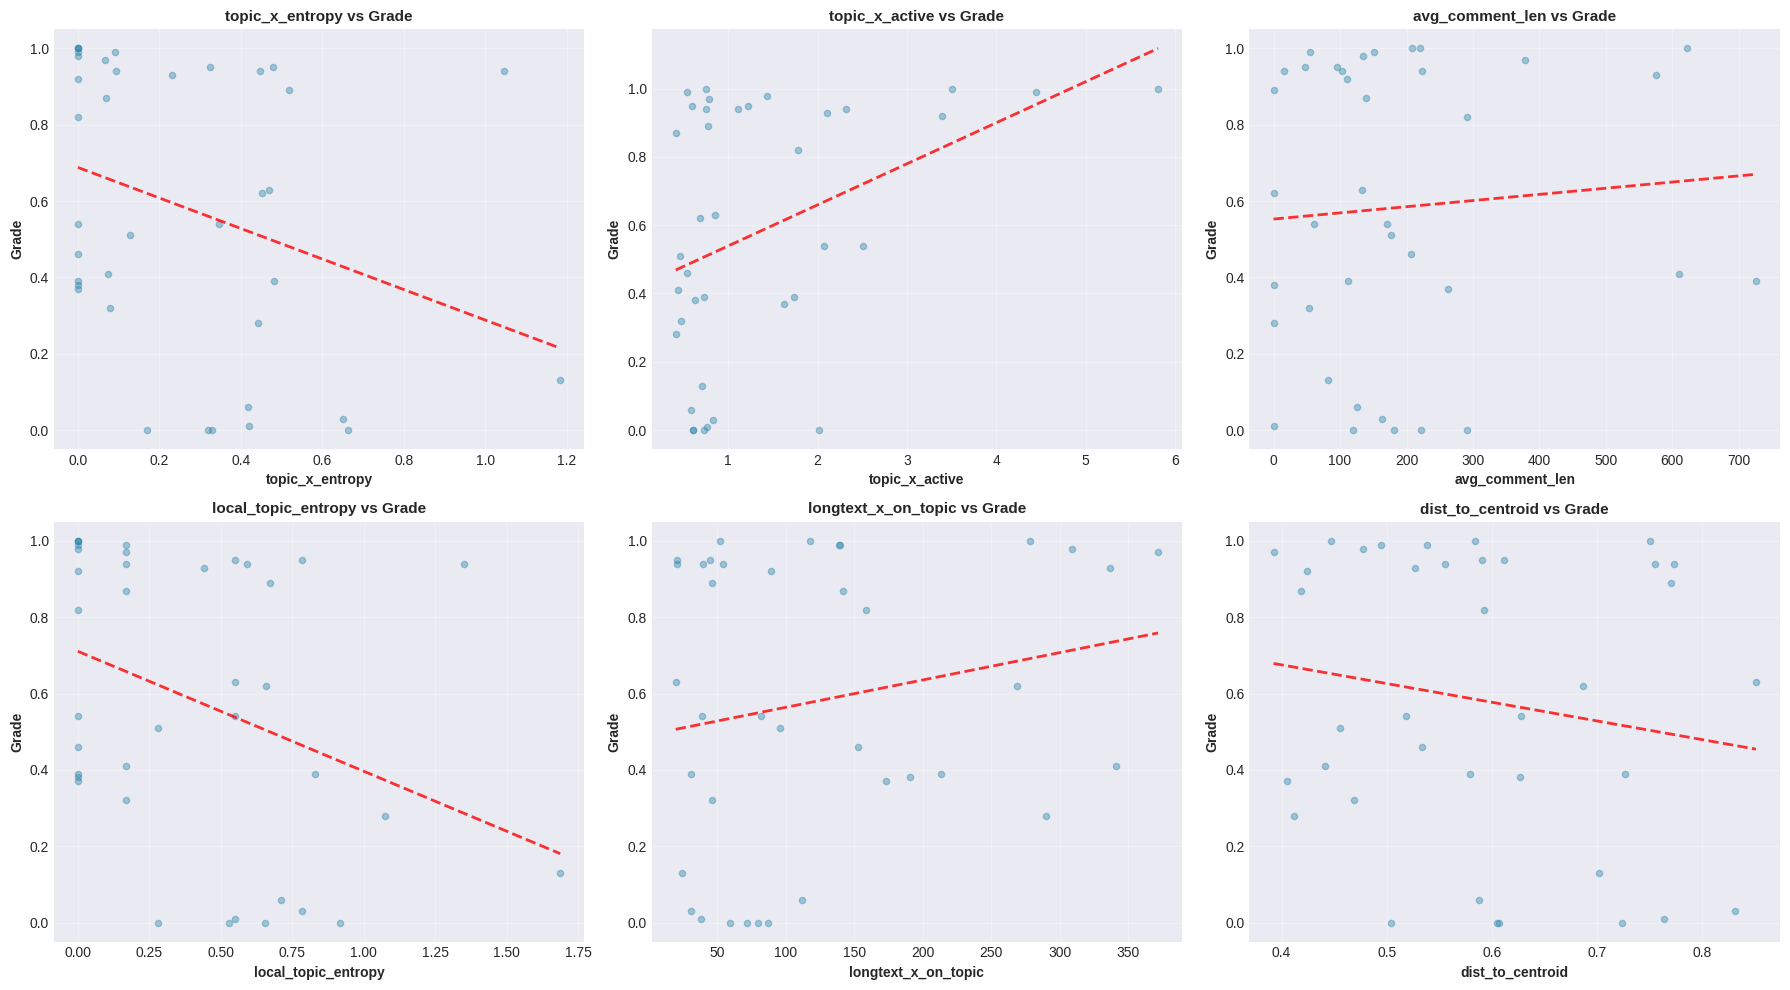

7. Learning Curves...


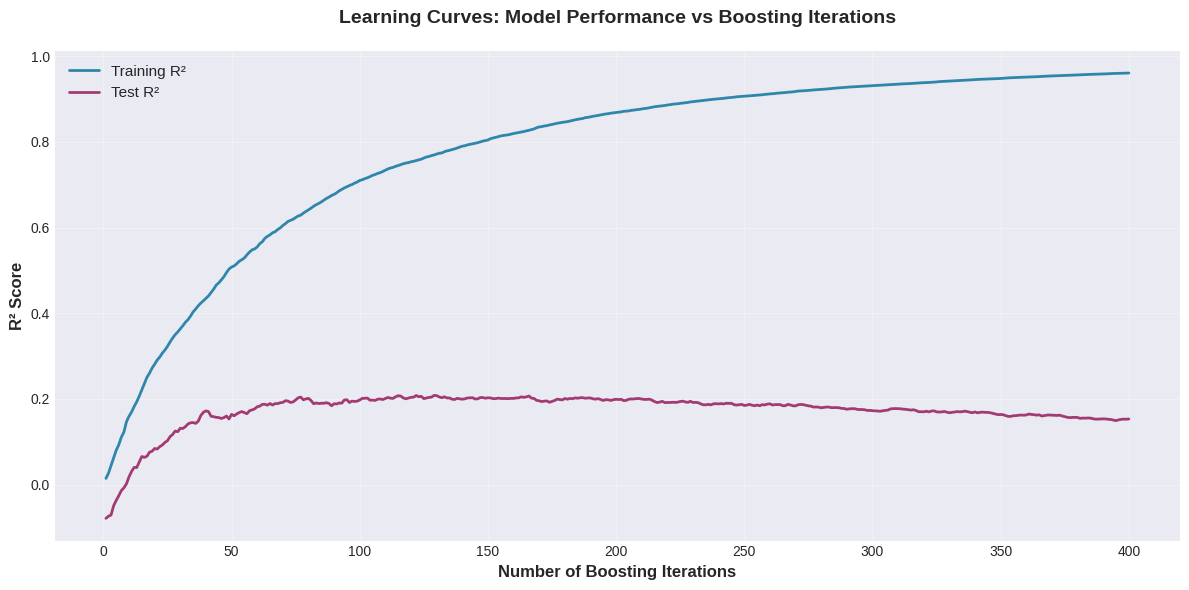

8. Feature Category Importance...


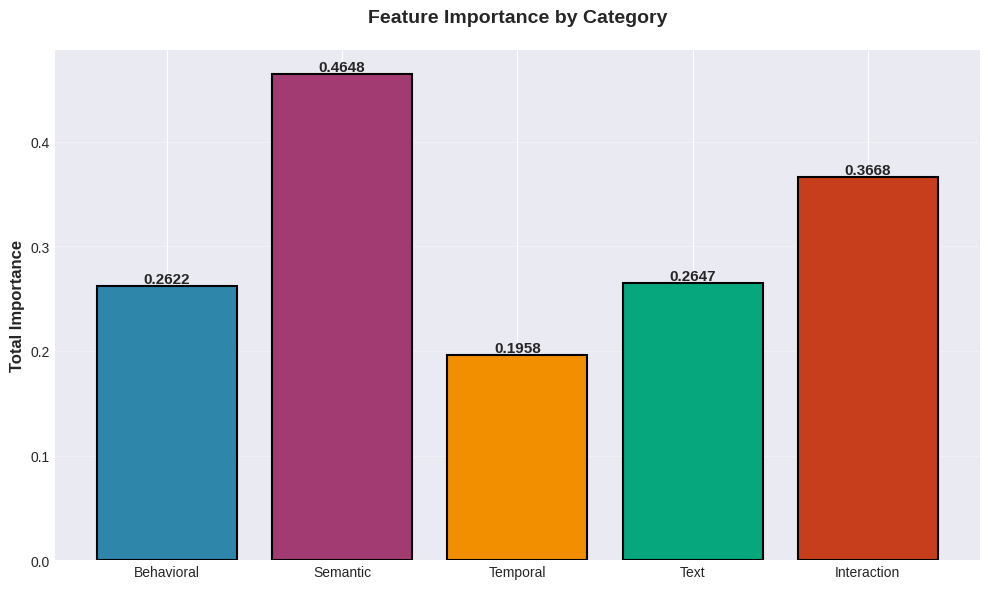

9. Distribution of Top Features...


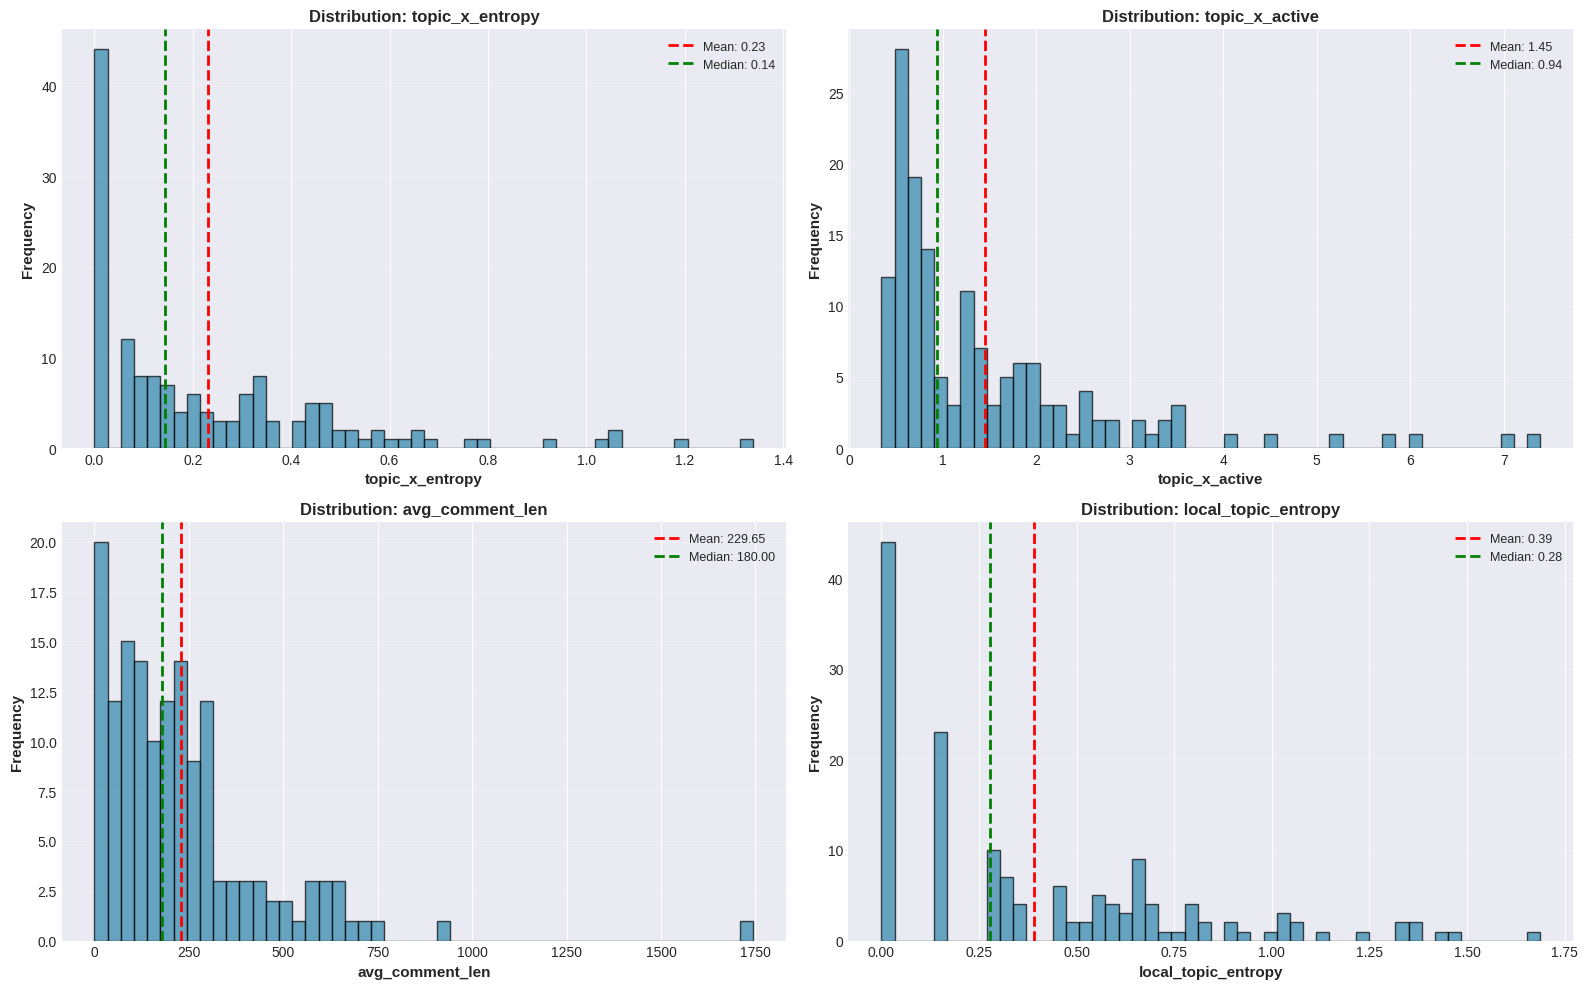

10. Partial Dependence Plots...


KeyError: 'values'

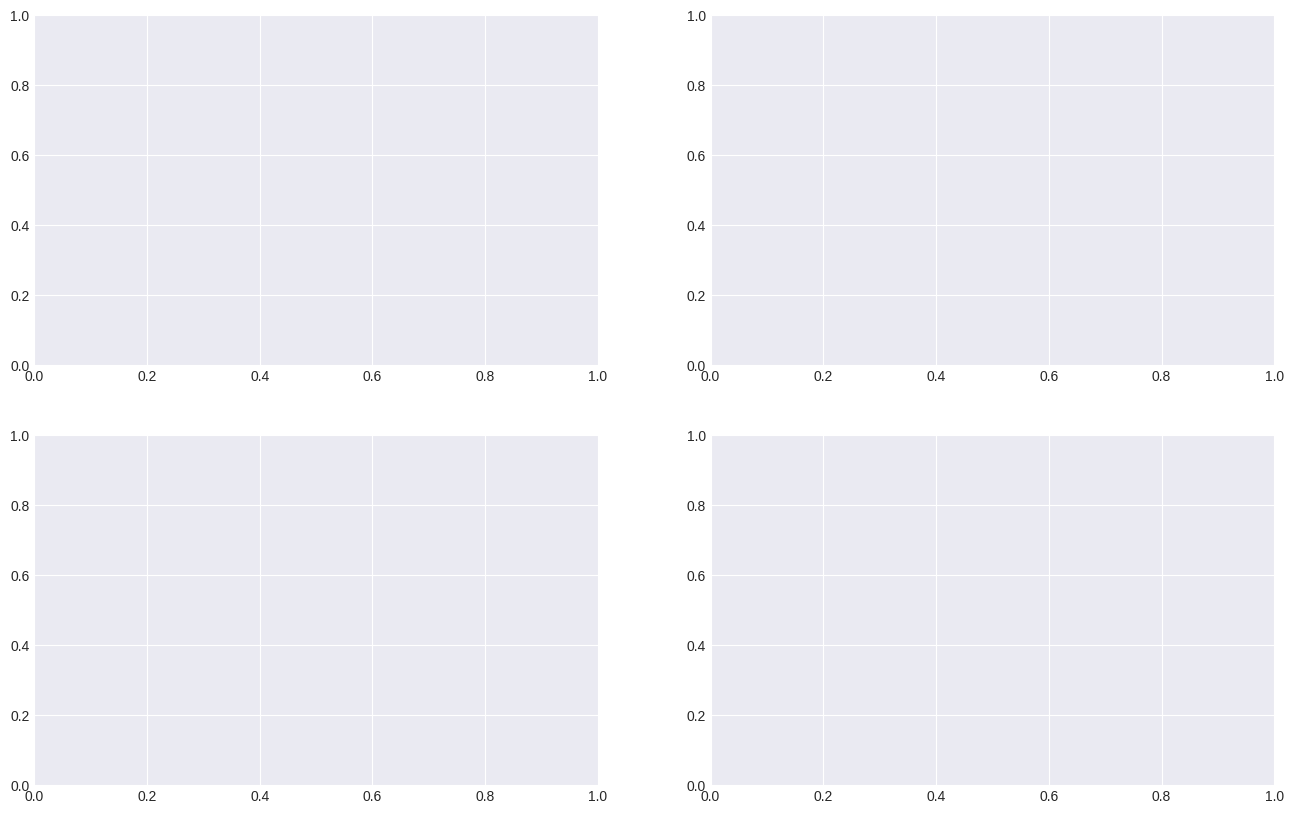

In [ ]:
# =========================
# Gradient Boosting Deep Dive: Forum Semantics + Time-Series → Grades
# Comprehensive Model Analysis & Visualization Suite
# =========================

# ==== 0) CONFIG: Set your file paths here ====
THREADS_CSV = "/content/Forum thread ferpa(in).csv"
COMMENTS_CSV = "/content/Forum comment ferpa(in).csv"
GRADES_CSV = "/content/edX data set_student grade(edX data).csv"
COURSE_WEEKS_MAX = 16
RANDOM_SEED = 42

# Output directory for visualizations (will be created if doesn't exist)
OUTPUT_DIR = "/content/outputs"

# ==== 1) Imports & setup ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence

import warnings
warnings.filterwarnings('ignore')

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 10

print("="*80)
print("GRADIENT BOOSTING COMPREHENSIVE ANALYSIS")
print("="*80)
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# ==== 2) Load data ====
print("Loading datasets...")
threads = pd.read_csv(THREADS_CSV, encoding="utf-8", on_bad_lines="skip")
comments = pd.read_csv(COMMENTS_CSV, encoding="utf-8", on_bad_lines="skip")
grades = pd.read_csv(GRADES_CSV, encoding="latin1", on_bad_lines="skip")

print(f"  - Threads: {len(threads):,} rows")
print(f"  - Comments: {len(comments):,} rows")
print(f"  - Grades: {len(grades):,} rows")

for df in [threads, comments]:
    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
for df in [threads, comments, grades]:
    if "user_id" in df.columns:
        df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")

if "percent_grade" not in grades.columns:
    raise ValueError("The grades CSV must contain a 'percent_grade' column (0–1).")

# ==== 3) Normalize to Week-of-Course (0–16) ====
print("\nNormalizing time to week-of-course...")
def add_weeks(df):
    if "course_id" not in df.columns:
        raise ValueError("Forum CSVs must include 'course_id'.")
    cs = df.groupby("course_id")["created_at"].min().rename("course_start")
    out = df.merge(cs, on="course_id", how="left")
    out["week_of_course"] = ((out["created_at"] - out["course_start"]).dt.days // 7).astype("Int64")
    return out

threads = add_weeks(threads)
comments = add_weeks(comments)

threads = threads[(threads["week_of_course"]>=0) & (threads["week_of_course"]<=COURSE_WEEKS_MAX)]
comments = comments[(comments["week_of_course"]>=0) & (comments["week_of_course"]<=COURSE_WEEKS_MAX)]

courses = sorted(list(set(pd.concat([threads["course_id"], comments["course_id"]]).dropna())))
print(f"Courses found: {len(courses)}")

# ==== 4) Per-student behavioral features (per course) ====
print("\nBuilding behavioral features per student...")
def per_student_features(course_id):
    t = threads[threads["course_id"]==course_id].copy()
    c = comments[comments["course_id"]==course_id].copy()

    t_user = t.groupby("user_id").agg(
        threads_posted=("id","count"),
        thread_upvotes=("upvotes","sum"),
        avg_thread_len=("body", lambda x: x.dropna().str.len().mean() if len(x.dropna()) else 0),
    )
    c_user = c.groupby("user_id").agg(
        replies_made=("id","count"),
        comment_upvotes=("upvotes","sum"),
        avg_comment_len=("body", lambda x: x.dropna().str.len().mean() if len(x.dropna()) else 0),
    )

    feats = t_user.join(c_user, how="outer").fillna(0)
    feats["total_posts"] = feats["threads_posted"] + feats["replies_made"]
    feats["upvotes_total"] = feats["thread_upvotes"] + feats["comment_upvotes"]
    feats["upvotes_per_post"] = feats["upvotes_total"] / feats["total_posts"].replace({0:1})
    feats["avg_text_len"] = feats.apply(
        lambda r: np.nanmean([
            r["avg_thread_len"] if r["avg_thread_len"]>0 else np.nan,
            r["avg_comment_len"] if r["avg_comment_len"]>0 else np.nan
        ]),
        axis=1
    )

    # Active weeks & early-activity & regularity
    tw = t.groupby(["user_id","week_of_course"]).size().rename("tw")
    cw = c.groupby(["user_id","week_of_course"]).size().rename("cw")
    wk = pd.concat([tw, cw], axis=1).fillna(0).reset_index()
    active_weeks = wk.groupby("user_id").size().rename("active_weeks")
    feats = feats.join(active_weeks, how="left").fillna({"active_weeks":0})

    wk["total"] = wk["tw"] + wk["cw"]
    early = wk[wk["week_of_course"]<=4].groupby("user_id")["total"].sum().rename("early_posts")
    allp = wk.groupby("user_id")["total"].sum().rename("all_posts")
    early_idx = early.to_frame().join(allp, how="right").fillna(0.0)
    early_idx["early_activity_index"] = early_idx["early_posts"] / early_idx["all_posts"].replace({0:1})
    feats = feats.join(early_idx["early_activity_index"], how="left").fillna({"early_activity_index":0.0})

    var_w = wk.groupby("user_id")["total"].var().rename("weekly_variance").fillna(0.0)
    feats = feats.join(var_w, how="left").fillna({"weekly_variance":0.0})

    # Merge grades
    if "course_id" in grades.columns:
        g = grades[grades["course_id"]==course_id][["user_id","percent_grade"]].drop_duplicates()
    else:
        g = grades[["user_id","percent_grade"]].drop_duplicates()
    feats = feats.reset_index().merge(g, on="user_id", how="left")
    feats["course_id"] = course_id
    return feats

features = pd.concat([per_student_features(cid) for cid in courses], ignore_index=True)
print(f"Feature matrix: {features.shape}")

# ==== 5) Build per-student corpus (threads + comments) ====
print("\nBuilding text corpus per student...")
def user_corpus(course_id):
    t = threads[threads["course_id"]==course_id][["user_id","body"]].dropna()
    c = comments[comments["course_id"]==course_id][["user_id","body"]].dropna()
    alltxt = pd.concat([t,c], ignore_index=True)
    return alltxt.groupby("user_id")["body"].apply(lambda x: "\n".join(x.astype(str))).reset_index()

corp_list = []
for cid in courses:
    df = user_corpus(cid)
    if len(df):
        df["course_id"] = cid
        corp_list.append(df)
corpus = pd.concat(corp_list, ignore_index=True) if len(corp_list) else pd.DataFrame(columns=["user_id","body","course_id"])
print(f"Corpus rows: {corpus.shape}")

# ==== 6) Embeddings (BERT if available; TF-IDF fallback) ====
print("\nGenerating text embeddings...")
USE_TFIDF = False
embed = None
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    def embed(texts):
        return model.encode(texts, show_progress_bar=False, normalize_embeddings=True)
    print("  Using BERT (all-MiniLM-L6-v2)")
except Exception:
    USE_TFIDF = True
    print("  BERT unavailable; using TF-IDF fallback")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    svd = TruncatedSVD(n_components=128, random_state=RANDOM_SEED)
    def embed(texts):
        X = vec.fit_transform(texts)
        return svd.fit_transform(X)

texts = corpus["body"].fillna("").astype(str).tolist()
if len(texts) == 0:
    emb = np.zeros((0, 128))
else:
    emb = embed(texts)
print(f"  Embeddings shape: {emb.shape}")

# ==== 7) Semantic metrics (cluster, entropy, on-topic distance) ====
print("\nComputing semantic metrics...")
sem = corpus[["course_id","user_id"]].copy()
if len(emb) > 0:
    k = min(8, max(2, emb.shape[0]//50))
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(emb)
    sem["cluster"] = labels

    centroids = {}
    for cid in sem["course_id"].unique():
        idx = (sem["course_id"]==cid).values
        centroids[cid] = emb[idx].mean(axis=0) if idx.sum() else np.zeros(emb.shape[1])

    def cos_dist(a, b):
        num = float(np.dot(a,b))
        den = (np.linalg.norm(a)+1e-9)*(np.linalg.norm(b)+1e-9)
        return 1.0 - (num/den)

    sem_vecs = emb
    sem["dist_to_centroid"] = [
        cos_dist(sem_vecs[i], centroids[sem.iloc[i]["course_id"]]) for i in range(len(sem))
    ]

    n_neighbors = min(25, len(sem))
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(sem_vecs)
    _, inds = nbrs.kneighbors(sem_vecs)
    loc_labels = labels[inds]

    def entropy(lbls):
        counts = Counter(lbls)
        p = np.array(list(counts.values()), dtype=float)
        p /= p.sum()
        return float(-(p*np.log(p+1e-12)).sum())

    sem["local_topic_entropy"] = [entropy(x) for x in loc_labels]
else:
    sem["cluster"] = np.nan
    sem["dist_to_centroid"] = np.nan
    sem["local_topic_entropy"] = np.nan

# ==== 8) Merge & build enhanced feature set ====
print("\nMerging features with semantic metrics...")
data = features.merge(sem, on=["course_id","user_id"], how="left")

# Get base numeric columns
num_cols = [
    c for c in data.columns
    if c not in ["course_id","user_id"] and pd.api.types.is_numeric_dtype(data[c])
]

# CRITICAL: Filter to only students with valid grades
print("\nFiltering to students with valid grades...")
print(f"Total students before filtering: {len(data):,}")

valid_grade_mask = data["percent_grade"].notna()
data_valid = data[valid_grade_mask].copy()

print(f"Students with valid grades: {len(data_valid):,}")
print(f"Students filtered out (no grade): {len(data) - len(data_valid):,}")
print(f"Percentage with grades: {100 * len(data_valid) / len(data):.1f}%")

# Build enhanced features with interactions (using only valid grade students)
X = data_valid[[c for c in num_cols if c != "percent_grade"]].copy()
get = X.get

print("\nEngineering interaction features...")
X["early_x_active"] = get("early_activity_index", 0.0) * get("active_weeks", 0.0)
X["topic_x_active"] = get("dist_to_centroid", 0.0) * get("active_weeks", 0.0)
X["topic_x_entropy"] = get("dist_to_centroid", 0.0) * get("local_topic_entropy", 0.0)
X["longtext_x_on_topic"] = get("avg_text_len", 0.0) * (1.0 - get("dist_to_centroid", 0.0))
X["early_active_ratio"] = X["early_activity_index"] / (X["active_weeks"] + 1)
X["consistency_score"] = 1.0 / (1.0 + X["weekly_variance"])
X["normalized_upvotes"] = X["upvotes_total"] / (X["total_posts"] + 1)

X = X.fillna(0.0)
y = data_valid["percent_grade"]  # No fillna needed - all grades are valid

print(f"\nFinal feature count: {X.shape[1]}")
print(f"Total samples for training: {X.shape[0]:,}")
print(f"Grade distribution: min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}, median={y.median():.2f}")

# Quick visualization of grade distribution (before train/test split)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y, bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(y.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.2f}')
axes[0].axvline(y.median(), color='g', linestyle='--', linewidth=2, label=f'Median: {y.median():.2f}')
axes[0].set_xlabel('Grade', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Grade Distribution (Students with Valid Grades)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
box = axes[1].boxplot(y, vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('#2E86AB')
box['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Grade', fontsize=12, fontweight='bold')
axes[1].set_title('Grade Distribution Box Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/00_grade_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGrade distribution visualization saved.")

# ==== 9) GRADIENT BOOSTING MODEL TRAINING ====
print("\n" + "="*80)
print("GRADIENT BOOSTING MODEL")
print("="*80)

if len(np.unique(y)) > 1 and X.shape[0] > 10:
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_SEED
    )

    print(f"\nTrain set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")

    # Train Gradient Boosting model
    print("\nTraining Gradient Boosting Regressor...")
    gb_model = GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=RANDOM_SEED,
        verbose=0
    )

    gb_model.fit(X_train, y_train)

    # Predictions
    y_pred_train = gb_model.predict(X_train)
    y_pred_test = gb_model.predict(X_test)

    # Performance metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print("\n" + "-"*50)
    print("MODEL PERFORMANCE METRICS")
    print("-"*50)
    print(f"Training R²:   {train_r2:.4f}")
    print(f"Test R²:       {test_r2:.4f}")
    print(f"Training MAE:  {train_mae:.4f} ({train_mae*100:.2f}% grade points)")
    print(f"Test MAE:      {test_mae:.4f} ({test_mae*100:.2f}% grade points)")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Test RMSE:     {test_rmse:.4f}")

    # Model parameters
    print("\n" + "-"*50)
    print("MODEL HYPERPARAMETERS")
    print("-"*50)
    print(f"Number of estimators: {gb_model.n_estimators}")
    print(f"Learning rate: {gb_model.learning_rate}")
    print(f"Max depth: {gb_model.max_depth}")
    print(f"Subsample ratio: {gb_model.subsample}")
    print(f"Min samples split: {gb_model.min_samples_split}")
    print(f"Min samples leaf: {gb_model.min_samples_leaf}")
    print(f"Max features: {gb_model.max_features}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n" + "-"*50)
    print("TOP 20 FEATURE IMPORTANCES")
    print("-"*50)
    for idx, row in feature_importance.head(20).iterrows():
        print(f"{row['feature']:35s} {row['importance']:.5f}")

    # ==== 10) COMPREHENSIVE VISUALIZATIONS ====
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)

    # Color schemes
    primary_color = '#2E86AB'
    secondary_color = '#A23B72'
    accent_color = '#F18F01'
    success_color = '#06A77D'

    # 1. Feature Importance (Top 20)
    print("\n1. Feature Importance Bar Chart...")
    fig, ax = plt.subplots(figsize=(12, 8))
    top_20 = feature_importance.head(20)
    bars = ax.barh(range(len(top_20)), top_20['importance'].values, color=primary_color)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['feature'].values)
    ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Features by Importance (Gradient Boosting)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.invert_yaxis()

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/01_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Feature Importance (Cumulative)
    print("2. Cumulative Feature Importance...")
    fig, ax = plt.subplots(figsize=(12, 6))
    cumsum = feature_importance['importance'].cumsum()
    ax.plot(range(1, len(cumsum)+1), cumsum, color=primary_color, linewidth=2)
    ax.axhline(y=0.8, color=accent_color, linestyle='--', linewidth=2, label='80% threshold')
    ax.axhline(y=0.9, color=secondary_color, linestyle='--', linewidth=2, label='90% threshold')
    ax.fill_between(range(1, len(cumsum)+1), cumsum, alpha=0.3, color=primary_color)
    ax.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
    ax.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/02_cumulative_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Predictions vs Actual (Train and Test)
    print("3. Predictions vs Actual Scatter Plots...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Training set
    axes[0].scatter(y_train, y_pred_train, alpha=0.5, s=30, color=primary_color, edgecolors='white', linewidth=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Grade', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Predicted Grade', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Test set
    axes[1].scatter(y_test, y_pred_test, alpha=0.5, s=30, color=secondary_color, edgecolors='white', linewidth=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual Grade', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Predicted Grade', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/03_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 4. Residual Plots
    print("4. Residual Analysis...")
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Residual scatter - train
    axes[0,0].scatter(y_pred_train, residuals_train, alpha=0.5, s=30, color=primary_color)
    axes[0,0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0,0].set_xlabel('Predicted Grade', fontsize=11, fontweight='bold')
    axes[0,0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
    axes[0,0].set_title('Residual Plot - Training Set', fontsize=12, fontweight='bold')
    axes[0,0].grid(True, alpha=0.3)

    # Residual scatter - test
    axes[0,1].scatter(y_pred_test, residuals_test, alpha=0.5, s=30, color=secondary_color)
    axes[0,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0,1].set_xlabel('Predicted Grade', fontsize=11, fontweight='bold')
    axes[0,1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
    axes[0,1].set_title('Residual Plot - Test Set', fontsize=12, fontweight='bold')
    axes[0,1].grid(True, alpha=0.3)

    # Residual histogram - train
    axes[1,0].hist(residuals_train, bins=50, color=primary_color, alpha=0.7, edgecolor='black')
    axes[1,0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1,0].set_xlabel('Residuals', fontsize=11, fontweight='bold')
    axes[1,0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1,0].set_title(f'Residual Distribution - Train (μ={residuals_train.mean():.4f})',
                        fontsize=12, fontweight='bold')
    axes[1,0].grid(True, alpha=0.3, axis='y')

    # Residual histogram - test
    axes[1,1].hist(residuals_test, bins=50, color=secondary_color, alpha=0.7, edgecolor='black')
    axes[1,1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1,1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
    axes[1,1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1,1].set_title(f'Residual Distribution - Test (μ={residuals_test.mean():.4f})',
                        fontsize=12, fontweight='bold')
    axes[1,1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_residual_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 5. Feature Correlation Heatmap (Top Features)
    print("5. Feature Correlation Heatmap...")
    top_features = feature_importance.head(15)['feature'].tolist()
    corr_matrix = X[top_features].corr()

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=ax)
    ax.set_title('Feature Correlation Matrix (Top 15 Important Features)',
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 6. Feature vs Grade Relationships (Top 6)
    print("6. Feature-Grade Relationship Scatter Plots...")
    top_6_features = feature_importance.head(6)['feature'].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feat in enumerate(top_6_features):
        axes[idx].scatter(X_test[feat], y_test, alpha=0.4, s=20, color=primary_color)
        axes[idx].set_xlabel(feat, fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Grade', fontsize=10, fontweight='bold')
        axes[idx].set_title(f'{feat} vs Grade', fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)

        # Add trend line
        z = np.polyfit(X_test[feat], y_test, 1)
        p = np.poly1d(z)
        x_line = np.linspace(X_test[feat].min(), X_test[feat].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/06_feature_grade_relationships.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. Learning Curves (staged predictions)
    print("7. Learning Curves...")
    train_scores = []
    test_scores = []

    for i, y_pred in enumerate(gb_model.staged_predict(X_train)):
        train_scores.append(r2_score(y_train, y_pred))

    for i, y_pred in enumerate(gb_model.staged_predict(X_test)):
        test_scores.append(r2_score(y_test, y_pred))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(range(1, len(train_scores)+1), train_scores, label='Training R²',
            color=primary_color, linewidth=2)
    ax.plot(range(1, len(test_scores)+1), test_scores, label='Test R²',
            color=secondary_color, linewidth=2)
    ax.set_xlabel('Number of Boosting Iterations', fontsize=12, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax.set_title('Learning Curves: Model Performance vs Boosting Iterations',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/07_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 8. Feature Categories Analysis
    print("8. Feature Category Importance...")

    # Categorize features
    behavioral_feats = [f for f in X.columns if any(x in f.lower() for x in
                       ['post', 'thread', 'comment', 'reply', 'upvote', 'active_weeks'])]
    semantic_feats = [f for f in X.columns if any(x in f.lower() for x in
                     ['topic', 'entropy', 'cluster', 'centroid'])]
    temporal_feats = [f for f in X.columns if any(x in f.lower() for x in
                     ['early', 'week', 'consistency', 'variance'])]
    text_feats = [f for f in X.columns if any(x in f.lower() for x in
                 ['len', 'text'])]
    interaction_feats = [f for f in X.columns if '_x_' in f.lower() or 'ratio' in f.lower()]

    categories = {
        'Behavioral': behavioral_feats,
        'Semantic': semantic_feats,
        'Temporal': temporal_feats,
        'Text': text_feats,
        'Interaction': interaction_feats
    }

    category_importance = {}
    for cat_name, cat_feats in categories.items():
        cat_importance = feature_importance[feature_importance['feature'].isin(cat_feats)]['importance'].sum()
        category_importance[cat_name] = cat_importance

    fig, ax = plt.subplots(figsize=(10, 6))
    cats = list(category_importance.keys())
    vals = list(category_importance.values())
    colors_cat = [primary_color, secondary_color, accent_color, success_color, '#C73E1D']
    bars = ax.bar(cats, vals, color=colors_cat, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Total Importance', fontsize=12, fontweight='bold')
    ax.set_title('Feature Importance by Category', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/08_category_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 9. Distribution of Top Features
    print("9. Distribution of Top Features...")
    top_4_features = feature_importance.head(4)['feature'].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for idx, feat in enumerate(top_4_features):
        axes[idx].hist(X[feat], bins=50, color=primary_color, alpha=0.7, edgecolor='black')
        axes[idx].set_xlabel(feat, fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Distribution: {feat}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Add statistics
        mean_val = X[feat].mean()
        median_val = X[feat].median()
        axes[idx].axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/09_feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 10. Partial Dependence Plots
    print("10. Partial Dependence Plots...")
    top_features_pd = feature_importance.head(4)['feature'].tolist()
    feature_indices = [X.columns.get_loc(f) for f in top_features_pd]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (feat_name, feat_idx) in enumerate(zip(top_features_pd, feature_indices)):
        pd_result = partial_dependence(gb_model, X_train, [feat_idx], grid_resolution=50)
        axes[idx].plot(pd_result['values'][0], pd_result['average'][0],
                      color=primary_color, linewidth=3)
        axes[idx].set_xlabel(feat_name, fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Partial Dependence', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Partial Dependence: {feat_name}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/10_partial_dependence.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 11. Error Distribution by Grade Bin
    print("11. Error Analysis by Grade Range...")
    y_test_array = y_test.values
    grade_bins = pd.cut(y_test_array, bins=[0, 0.6, 0.7, 0.8, 0.9, 1.0],
                        labels=['<60%', '60-70%', '70-80%', '80-90%', '90-100%'])
    error_by_bin = pd.DataFrame({
        'grade_bin': grade_bins,
        'error': np.abs(residuals_test)
    })

    fig, ax = plt.subplots(figsize=(12, 6))
    error_by_bin.boxplot(column='error', by='grade_bin', ax=ax)
    ax.set_xlabel('Grade Range', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
    ax.set_title('Prediction Error Distribution by Grade Range', fontsize=14, fontweight='bold')
    plt.suptitle('')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/11_error_by_grade_range.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 12. Time-Series Analysis: Weekly Engagement vs Grades
    print("12. Weekly Engagement Patterns...")

    def weekly_mean_grade(course_id):
        if "course_id" in grades.columns:
            g = grades[grades["course_id"]==course_id][["user_id","percent_grade"]].drop_duplicates()
        else:
            g = grades[["user_id","percent_grade"]].drop_duplicates()
        t_u = threads[threads["course_id"]==course_id].groupby(["user_id","week_of_course"]).size().rename("t")
        c_u = comments[comments["course_id"]==course_id].groupby(["user_id","week_of_course"]).size().rename("c")
        wk = pd.concat([t_u, c_u], axis=1).fillna(0).reset_index()
        wk["total"] = wk[["t","c"]].sum(axis=1)
        wk = wk.merge(g, on="user_id", how="left")
        if len(wk)==0:
            return pd.DataFrame({"week_of_course":[0], "mean_grade":[0.0]})
        agg = wk.groupby("week_of_course").apply(
            lambda d: (d["percent_grade"]*d["total"]).sum()/max(d["total"].sum(),1)
        ).rename("mean_grade").reset_index()
        return agg

    fig, ax = plt.subplots(figsize=(14, 7))
    for idx, cid in enumerate(courses[:8]):  # Plot first 8 courses
        agg = weekly_mean_grade(cid)
        label = cid.split("+")[1] if isinstance(cid, str) and "+" in cid else str(cid)
        ax.plot(agg["week_of_course"], agg["mean_grade"], marker="o",
               label=label, linewidth=2, markersize=5, alpha=0.8)

    ax.set_xlabel('Week of Course', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weighted Mean Grade', fontsize=12, fontweight='bold')
    ax.set_title('Weekly Engagement-Weighted Mean Grade Across Courses',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/12_weekly_grade_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 13. Feature Interaction Heatmap (Top interaction features)
    print("13. Feature Interaction Analysis...")
    interaction_features = [f for f in X.columns if '_x_' in f or 'ratio' in f.lower()]
    if len(interaction_features) >= 5:
        interact_data = X_test[interaction_features[:5]].copy()
        interact_data['grade'] = y_test.values

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(interact_data.corr(), annot=True, fmt='.3f',
                   cmap='coolwarm', center=0, square=True, linewidths=1,
                   cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title('Interaction Features Correlation with Grades',
                    fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/13_interaction_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

    # 14. Model Metrics Summary Dashboard
    print("14. Model Metrics Dashboard...")
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # Metric boxes
    metrics = [
        ('Test R²', test_r2, 0, 0),
        ('Train R²', train_r2, 0, 1),
        ('Test MAE', test_mae, 0, 2),
        ('Train MAE', train_mae, 1, 0),
        ('Test RMSE', test_rmse, 1, 1),
        ('Train RMSE', train_rmse, 1, 2),
    ]

    for metric_name, value, row, col in metrics:
        ax = fig.add_subplot(gs[row, col])
        ax.text(0.5, 0.5, f'{value:.4f}', ha='center', va='center',
               fontsize=32, fontweight='bold', color=primary_color)
        ax.text(0.5, 0.15, metric_name, ha='center', va='center',
               fontsize=14, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False,
                                   edgecolor=primary_color, linewidth=3))

    # Bottom row: Top 5 features
    ax_bottom = fig.add_subplot(gs[2, :])
    top_5 = feature_importance.head(5)
    bars = ax_bottom.barh(range(len(top_5)), top_5['importance'].values,
                         color=primary_color, edgecolor='black', linewidth=1.5)
    ax_bottom.set_yticks(range(len(top_5)))
    ax_bottom.set_yticklabels(top_5['feature'].values)
    ax_bottom.set_xlabel('Importance', fontsize=11, fontweight='bold')
    ax_bottom.set_title('Top 5 Most Important Features', fontsize=12, fontweight='bold')
    ax_bottom.invert_yaxis()

    plt.suptitle('Gradient Boosting Model Performance Dashboard',
                fontsize=16, fontweight='bold', y=0.98)
    plt.savefig(f'{OUTPUT_DIR}/14_metrics_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 15. Prediction Confidence Analysis
    print("15. Prediction Confidence Analysis...")

    # Calculate prediction intervals using quantile regression approach
    confidence_levels = [0.1, 0.5, 0.9]

    fig, ax = plt.subplots(figsize=(12, 7))

    # Sort by actual grades for visualization
    sort_idx = np.argsort(y_test)
    y_test_sorted = y_test.iloc[sort_idx]
    y_pred_sorted = y_pred_test[sort_idx]

    ax.scatter(range(len(y_test_sorted)), y_test_sorted,
              alpha=0.3, s=20, color=primary_color, label='Actual Grades')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted,
           color=secondary_color, linewidth=2, label='Predictions', alpha=0.8)

    ax.set_xlabel('Sample (sorted by actual grade)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Grade', fontsize=12, fontweight='bold')
    ax.set_title('Prediction Confidence: Actual vs Predicted (Sorted)',
                fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/15_prediction_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nAll visualizations saved to: {OUTPUT_DIR}/")
    print(f"Total visualizations generated: 16")
    print(f"  - 00_grade_distribution.png (initial data exploration)")
    print(f"  - 01-15: model analysis and feature insights")
    print(f"\nAnalysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Save summary report
    with open(f'{OUTPUT_DIR}/model_summary_report.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("GRADIENT BOOSTING MODEL - COMPREHENSIVE ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("DATASET INFORMATION\n")
        f.write("-"*50 + "\n")
        f.write(f"Total Students (with valid grades): {X.shape[0]:,}\n")
        f.write(f"Total Features: {X.shape[1]}\n")
        f.write(f"Training Samples: {X_train.shape[0]:,}\n")
        f.write(f"Test Samples: {X_test.shape[0]:,}\n")
        f.write(f"Number of Courses: {len(courses)}\n")
        f.write(f"\nGrade Distribution:\n")
        f.write(f"  Min: {y.min():.4f}\n")
        f.write(f"  Max: {y.max():.4f}\n")
        f.write(f"  Mean: {y.mean():.4f}\n")
        f.write(f"  Median: {y.median():.4f}\n")
        f.write(f"  Std Dev: {y.std():.4f}\n\n")
        f.write("NOTE: Analysis includes only students with valid grades.\n")
        f.write("Students without grades were excluded from the model.\n\n")

        f.write("MODEL HYPERPARAMETERS\n")
        f.write("-"*50 + "\n")
        f.write(f"Number of Estimators: {gb_model.n_estimators}\n")
        f.write(f"Learning Rate: {gb_model.learning_rate}\n")
        f.write(f"Max Depth: {gb_model.max_depth}\n")
        f.write(f"Subsample: {gb_model.subsample}\n")
        f.write(f"Min Samples Split: {gb_model.min_samples_split}\n")
        f.write(f"Min Samples Leaf: {gb_model.min_samples_leaf}\n")
        f.write(f"Max Features: {gb_model.max_features}\n\n")

        f.write("PERFORMANCE METRICS\n")
        f.write("-"*50 + "\n")
        f.write(f"Training R²:   {train_r2:.4f}\n")
        f.write(f"Test R²:       {test_r2:.4f}\n")
        f.write(f"Training MAE:  {train_mae:.4f} ({train_mae*100:.2f}% grade points)\n")
        f.write(f"Test MAE:      {test_mae:.4f} ({test_mae*100:.2f}% grade points)\n")
        f.write(f"Training RMSE: {train_rmse:.4f}\n")
        f.write(f"Test RMSE:     {test_rmse:.4f}\n\n")

        f.write("TOP 20 FEATURE IMPORTANCES\n")
        f.write("-"*50 + "\n")
        for idx, row in feature_importance.head(20).iterrows():
            f.write(f"{row['feature']:35s} {row['importance']:.5f}\n")

        f.write("\n" + "="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")

    print(f"\nModel summary report saved to: {OUTPUT_DIR}/model_summary_report.txt")

else:
    print("\nInsufficient data for model training. Please check your input files.")

In [ ]:
# ===========================================
# EXPORT COMBINED THREADS & COMMENTS FOR USERS WITH GRADES
# ===========================================

import pandas as pd

# ==== CONFIG: Set your file paths ====
THREADS_CSV = "/content/Forum thread ferpa(in).csv"
COMMENTS_CSV = "/content/Forum comment ferpa(in).csv"
GRADES_CSV = "/content/edX data set_student grade(edX data).csv"

# Output path
OUTPUT_FILE = "/content/forum_posts_with_grades.csv"

# ==== Load data ====
print("Loading data...")
threads = pd.read_csv(THREADS_CSV, encoding="utf-8", on_bad_lines="skip")
comments = pd.read_csv(COMMENTS_CSV, encoding="utf-8", on_bad_lines="skip")
grades = pd.read_csv(GRADES_CSV, encoding="latin1", on_bad_lines="skip")

# Convert user_id to numeric for all dataframes
for df in [threads, comments, grades]:
    if "user_id" in df.columns:
        df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")

print(f"Initial threads: {len(threads):,}")
print(f"Initial comments: {len(comments):,}")
print(f"Total rows in grades file: {len(grades):,}")

# ==== CRITICAL: Filter grades to only non-null percent_grade values ====
grades_clean = grades.dropna(subset=["percent_grade"]).copy()
print(f"Users with valid grades: {grades_clean['user_id'].nunique():,}")

# ==== Get set of user_ids that have VALID grades ====
users_with_grades = set(grades_clean["user_id"].dropna().unique())
print(f"\nFiltering to {len(users_with_grades):,} users with valid grades...")

# ==== Filter to only users with valid grades ====
threads_filtered = threads[threads["user_id"].isin(users_with_grades)].copy()
comments_filtered = comments[comments["user_id"].isin(users_with_grades)].copy()

print(f"Threads after filtering: {len(threads_filtered):,}")
print(f"Comments after filtering: {len(comments_filtered):,}")

# ==== Add post_type column ====
threads_filtered["post_type"] = "thread"
comments_filtered["post_type"] = "comment"

# ==== Standardize columns ====
# Add missing columns to threads
if "thread_id" not in threads_filtered.columns:
    threads_filtered["thread_id"] = pd.NA
if "parent_id" not in threads_filtered.columns:
    threads_filtered["parent_id"] = pd.NA

# Add missing columns to comments
if "title" not in comments_filtered.columns:
    comments_filtered["title"] = pd.NA
if "view_count" not in comments_filtered.columns:
    comments_filtered["view_count"] = pd.NA

# ==== Select common columns ====
common_columns = [
    "post_type",
    "course_id",
    "user_id",
    "id",
    "created_at",
    "title",
    "body",
    "upvotes",
    "thread_id",
    "parent_id",
    "view_count"
]

# Only keep columns that exist in both dataframes
available_columns = [col for col in common_columns
                     if col in threads_filtered.columns and col in comments_filtered.columns]

threads_export = threads_filtered[available_columns]
comments_export = comments_filtered[available_columns]

# ==== Combine threads and comments ====
combined = pd.concat([threads_export, comments_export], ignore_index=True)

print(f"\nCombined posts before grade merge: {len(combined):,}")
print(f"  - Threads: {len(combined[combined['post_type']=='thread']):,}")
print(f"  - Comments: {len(combined[combined['post_type']=='comment']):,}")

# ==== Merge with grades (using cleaned grades only) ====
grade_cols = ["user_id", "percent_grade"]
if "course_id" in grades_clean.columns:
    grade_cols.append("course_id")

grades_to_merge = grades_clean[grade_cols].drop_duplicates()

# Merge on user_id and course_id if available
if "course_id" in grades_to_merge.columns and "course_id" in combined.columns:
    combined_with_grades = combined.merge(
        grades_to_merge,
        on=["user_id", "course_id"],
        how="inner"  # Changed to inner join to only keep matches
    )
else:
    combined_with_grades = combined.merge(
        grades_to_merge,
        on="user_id",
        how="inner"  # Changed to inner join to only keep matches
    )

# ==== Double-check: Remove any rows with null grades (safety check) ====
before_drop = len(combined_with_grades)
combined_with_grades = combined_with_grades.dropna(subset=["percent_grade"])
after_drop = len(combined_with_grades)

if before_drop > after_drop:
    print(f"\nWarning: Dropped {before_drop - after_drop} rows with null grades after merge")

# ==== Sort by course, user, and date ====
if "created_at" in combined_with_grades.columns:
    combined_with_grades["created_at"] = pd.to_datetime(
        combined_with_grades["created_at"],
        errors="coerce"
    )
    combined_with_grades = combined_with_grades.sort_values(
        ["course_id", "user_id", "created_at"]
    )

# ==== Export to CSV ====
combined_with_grades.to_csv(OUTPUT_FILE, index=False)

print(f"\n✓ Combined file exported to: {OUTPUT_FILE}")
print(f"  Columns: {list(combined_with_grades.columns)}")

# ==== Summary statistics ====
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total rows exported: {len(combined_with_grades):,}")
print(f"  - Threads: {len(combined_with_grades[combined_with_grades['post_type']=='thread']):,}")
print(f"  - Comments: {len(combined_with_grades[combined_with_grades['post_type']=='comment']):,}")
print(f"\nUnique users: {combined_with_grades['user_id'].nunique():,}")
print(f"Unique courses: {combined_with_grades['course_id'].nunique()}")
print(f"\nGrade statistics:")
print(f"  - Average grade: {combined_with_grades['percent_grade'].mean():.3f}")
print(f"  - Min grade: {combined_with_grades['percent_grade'].min():.3f}")
print(f"  - Max grade: {combined_with_grades['percent_grade'].max():.3f}")
print(f"  - Posts with missing grades: {combined_with_grades['percent_grade'].isna().sum():,}")

# Verify no null grades remain
assert combined_with_grades['percent_grade'].isna().sum() == 0, "ERROR: Null grades still present!"
print("\n✓ VERIFIED: All rows have valid grades")

# Show sample of the data
print("\n" + "="*60)
print("SAMPLE DATA (first 5 rows)")
print("="*60)
print(combined_with_grades[["post_type", "user_id", "course_id", "body", "percent_grade"]].head())

Loading data...
Initial threads: 9,284
Initial comments: 9,188
Total rows in grades file: 848
Users with valid grades: 242

Filtering to 242 users with valid grades...
Threads after filtering: 729
Comments after filtering: 3,446

Combined posts before grade merge: 4,175
  - Threads: 729
  - Comments: 3,446

✓ Combined file exported to: /content/forum_posts_with_grades.csv
  Columns: ['post_type', 'course_id', 'user_id', 'id', 'created_at', 'title', 'body', 'upvotes', 'thread_id', 'parent_id', 'percent_grade']

SUMMARY STATISTICS
Total rows exported: 3,365
  - Threads: 560
  - Comments: 2,805

Unique users: 209
Unique courses: 2

Grade statistics:
  - Average grade: 0.744
  - Min grade: 0.000
  - Max grade: 1.000
  - Posts with missing grades: 0

✓ VERIFIED: All rows have valid grades

SAMPLE DATA (first 5 rows)
    post_type  user_id                     course_id  \
881   comment     5710  course-v1:GTx+CS1301x+1T2017   
875   comment     5710  course-v1:GTx+CS1301x+1T2017   
91     th

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

OUTPUT_CSV = "/content/forum_user_features_bestmodel_with_descriptions_only_graded.csv"

# 1) Merge features + semantics
data = features.merge(sem, on=["course_id", "user_id"], how="left")

# 2) Keep ONLY users with real grades
if "percent_grade" not in data.columns:
    raise ValueError("percent_grade not found in merged data.")

before_n = data.shape[0]
data = data[data["percent_grade"].notna()].copy()
after_n = data.shape[0]
print(f"Rows before filtering: {before_n}, after keeping only graded users: {after_n}")

# 3) Add actual grade column (for clarity)
data["actual_grade"] = data["percent_grade"]  # 0–1, same as percent_grade

# 4) Build base feature matrix (same setup as best model: GB on base features)
num_cols = [
    c for c in data.columns
    if c not in ["course_id", "user_id"] and pd.api.types.is_numeric_dtype(data[c])
]

# We do NOT use 'percent_grade' itself as a feature
feature_cols = [c for c in num_cols if c != "percent_grade"]

X_base = data[feature_cols].fillna(0.0)
y = data["percent_grade"].astype(float)

print("Base feature matrix shape (graded users only):", X_base.shape)

# 5) Fit Gradient Boosting on this graded subset (best-performing model)
gb_full = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_SEED,
)
gb_full.fit(X_base, y)

# Predicted grade from best model
data["gb_grade_pred"] = gb_full.predict(X_base)

# 6) Reorder columns so important ones are first
front_cols = ["course_id", "user_id", "actual_grade", "gb_grade_pred"]
other_cols = [c for c in data.columns if c not in front_cols]
data = data[front_cols + other_cols]

# 7) Column descriptions (header explanations)
col_desc = {
    # IDs + targets
    "course_id": "Course identifier (e.g., specific MOOC run/term).",
    "user_id": "Numeric student/user identifier (anonymized).",
    "percent_grade": "Final course grade on a 0–1 scale (1.0 = 100%).",
    "actual_grade": "Same as percent_grade: final grade on a 0–1 scale for this user in this course.",
    "gb_grade_pred": "Predicted grade from Gradient Boosting using base behavioral + semantic features (best R^2 model).",

    # Core behavioral features
    "threads_posted": "Number of forum threads started by this user.",
    "thread_upvotes": "Total upvotes received on this user’s threads.",
    "avg_thread_len": "Average character length of this user’s thread bodies.",
    "replies_made": "Number of replies/comments this user posted.",
    "comment_upvotes": "Total upvotes received on this user’s comments.",
    "avg_comment_len": "Average character length of this user’s comments.",
    "total_posts": "threads_posted + replies_made (total forum posts).",
    "upvotes_total": "thread_upvotes + comment_upvotes (total upvotes).",
    "upvotes_per_post": "upvotes_total divided by total_posts (0 if no posts).",
    "avg_text_len": "Average text length across all posts (overall verbosity).",

    # Temporal / activity pattern features
    "active_weeks": "Number of distinct weeks (0–16) in which this user posted at least once.",
    "early_activity_index": "Share of user’s posts that occurred in weeks 0–4 (early engagement).",
    "weekly_variance": "Variance of weekly post counts (higher = more bursty, less consistent).",

    # Semantic features
    "cluster": "Integer topic cluster label from KMeans on text embeddings.",
    "dist_to_centroid": "Cosine distance between user’s text embedding and the course’s topic centroid (higher = more off-topic).",
    "local_topic_entropy": "Entropy of topic labels among nearest-neighbor posts (higher = more topic diversity).",

    # If you also have engineered features from earlier runs and they’re in `data`,
    # these descriptions will populate; otherwise they’ll just be blank.
    "early_x_active": "early_activity_index * active_weeks (strength of early engagement across weeks).",
    "topic_x_active": "dist_to_centroid * active_weeks (off-topic posting scaled by activity).",
    "topic_x_entropy": "dist_to_centroid * local_topic_entropy (off-topic and spread across many topics).",
    "longtext_x_on_topic": "avg_text_len * (1 - dist_to_centroid) (long, on-topic posts).",
    "early_active_ratio": "early_activity_index / (active_weeks + 1) (concentration of early posts).",
    "consistency_score": "1 / (1 + weekly_variance) (higher = more consistent posting).",
    "normalized_upvotes": "upvotes_total / (total_posts + 1) (upvotes per post, smoothed).",
}

# 8) Build description row aligned with current columns
desc_row = {col: col_desc.get(col, "") for col in data.columns}

# 9) Prepend description row and save
df_with_desc = pd.concat(
    [pd.DataFrame([desc_row]), data],
    ignore_index=True
)

df_with_desc.to_csv(OUTPUT_CSV, index=False)
print(f"Saved CSV with descriptions (only graded users) to: {OUTPUT_CSV}")
print("Number of rows (including description row):", df_with_desc.shape[0])
print("Number of columns:", df_with_desc.shape[1])


Rows before filtering: 4236, after keeping only graded users: 149
Base feature matrix shape (graded users only): (149, 17)
Saved CSV with descriptions (only graded users) to: /content/forum_user_features_bestmodel_with_descriptions_only_graded.csv
Number of rows (including description row): 150
Number of columns: 21
